# Image Classification using Convolutional Neural Networks (CNN)

This notebook demonstrates an image classification task using Convolutional Neural Networks (CNNs) in TensorFlow/Keras. The goal is to classify images of cats and dogs from the Cats vs Dogs dataset. The notebook covers data understanding, preprocessing, model development, training, and evaluation.

# Task 1: Data Understanding

In [ ]:
# 1. Import all required libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Although not strictly used for image data directly, it's a common ML library
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# 2. Set the dataset path
dataset_path = "/content/extracted_data/PetImages"

# Verify that the path exists
if os.path.exists(dataset_path):
    print(f"Dataset path set to: {dataset_path}")
else:
    print(f"Error: Dataset path '{dataset_path}' does not exist. Please check the extraction.")

Dataset path set to: /content/extracted_data/PetImages


In [ ]:
# 3. Display the folder structure
print("Displaying folder structure within the dataset directory:")
if os.path.exists(dataset_path):
    for dirpath, dirnames, filenames in os.walk(dataset_path):
        # Indent for better readability
        level = dirpath.replace(dataset_path, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(dirpath)}/')
        subindent = ' ' * 4 * (level + 1)
        for d in dirnames:
            print(f'{subindent}{d}/')
        # Display a few files to indicate content, but not all
        for f in filenames[:3]: # Show up to 3 files
            print(f'{subindent}{f}')
        if len(filenames) > 3:
            print(f'{subindent}...')
    print("Folder structure displayed.")
else:
    print(f"Cannot display folder structure: '{dataset_path}' does not exist.")

Displaying folder structure within the dataset directory:
PetImages/
    Cat/
    Dog/
    Cat/
        4902.jpg
        4375.jpg
        5983.jpg
        ...
    Dog/
        4902.jpg
        4375.jpg
        5983.jpg
        ...
Folder structure displayed.


Found 24998 images belonging to 2 classes.

Displaying five sample images from the dataset:


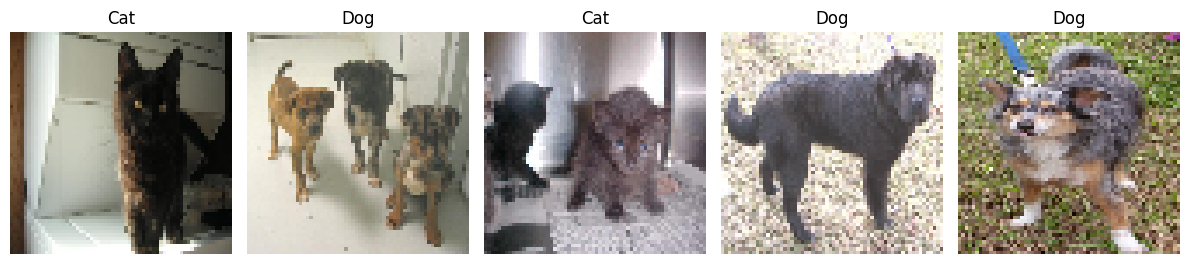


Dataset Properties:
- Number of classes: 2
- Class names: ['Cat', 'Dog']
- Sample image dimensions (H, W, C): (64, 64, 3) (Actual dimensions for model will be 128x128 later)
Found 24998 images belonging to 2 classes.
- Total number of images in dataset: 24998


In [ ]:
# Configure a generator for initial inspection and sample display
# We'll use a small target_size just for displaying samples quickly

# Use a temporary ImageDataGenerator for displaying samples
display_datagen = ImageDataGenerator(rescale=1./255)

# Flow from directory to get sample images and class labels
if os.path.exists(dataset_path):
    sample_generator = display_datagen.flow_from_directory(
        dataset_path,
        target_size=(64, 64), # Small size for quick display
        batch_size=5, # Get 5 images
        class_mode='binary',
        shuffle=True,
        seed=42 # For reproducibility of samples
    )

    # 4. Display five sample images with their class labels
    print("\nDisplaying five sample images from the dataset:")
    images, labels = next(sample_generator)

    plt.figure(figsize=(12, 8))
    class_names = list(sample_generator.class_indices.keys())

    for i in range(len(images)):
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[int(labels[i])])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    # 5. Identify dataset properties
    print("\nDataset Properties:")

    # Number of classes
    num_classes = len(class_names)
    print(f"- Number of classes: {num_classes}")
    print(f"- Class names: {class_names}")

    # Image dimensions (from the first loaded image, will be resized later)
    if images.shape[1:]:
        # (height, width, channels)
        image_dimensions = images.shape[1:]
        print(f"- Sample image dimensions (H, W, C): {image_dimensions} (Actual dimensions for model will be 128x128 later)")
    else:
        print("- Image dimensions could not be determined from samples.")

    # Total number of images
    # Create a separate generator just to count images
    total_images_count_generator = display_datagen.flow_from_directory(
        dataset_path,
        target_size=(64, 64),
        batch_size=1,
        class_mode='binary',
        shuffle=False
    )
    total_images_in_dataset = total_images_count_generator.samples

    print(f"- Total number of images in dataset: {total_images_in_dataset}")
else:
    print(f"Cannot perform Task 1: Data Understanding as '{dataset_path}' does not exist.")

# Task 2: Data Preprocessing

In [ ]:
# Define image parameters for preprocessing
IMG_WIDTH = 128
IMG_HEIGHT = 128
BATCH_SIZE = 32 # A common batch size for training

print(f"Image dimensions set to {IMG_WIDTH}x{IMG_HEIGHT} pixels and batch size to {BATCH_SIZE}.")

Image dimensions set to 128x128 pixels and batch size to 32.


Found 20000 images belonging to 2 classes.

Training data generator created.
Found 4998 images belonging to 2 classes.
Validation/Test data generator created.

Dataset Split Statistics:
- Number of training images: 20000
- Number of validation/testing images: 4998

Class indices:
{'Cat': 0, 'Dog': 1}

Displaying a batch of preprocessed images from the training generator:


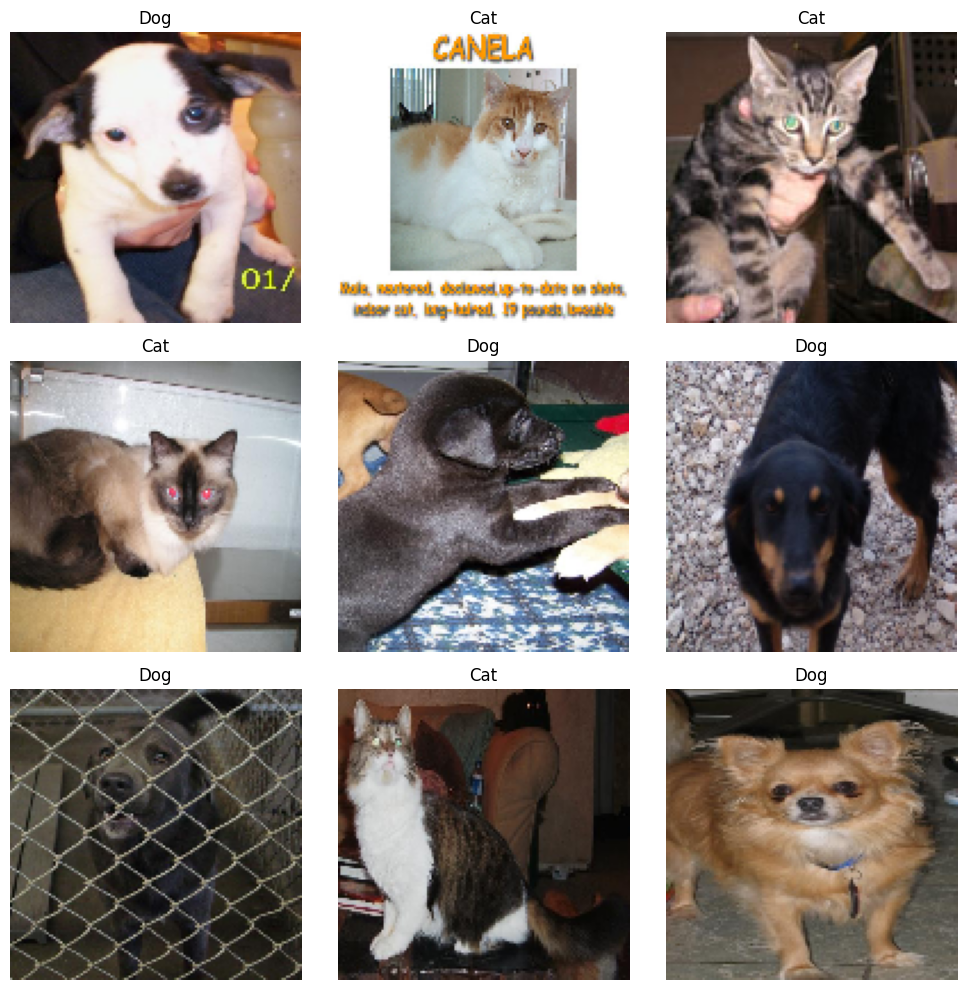

In [ ]:
# Create ImageDataGenerators for training and validation
# 1. Resize all images to 128 \u00d7 128 pixels (handled by target_size)
# 2. Normalize pixel values to the range 0\u20131 (handled by rescale=1./255)
# 3. Use validation_split=0.2 for an 80/20 train/validation split

if os.path.exists(dataset_path):
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.2 # 20% of the data will be used for validation
    )

    # Create Training Generator (80%)
    train_generator = train_datagen.flow_from_directory(
        dataset_path,
        target_size=(IMG_WIDTH, IMG_HEIGHT),
        batch_size=BATCH_SIZE,
        class_mode='binary', # 'binary' for 2 classes (cats/dogs)
        subset='training', # Specify this as the training set
        shuffle=True,
        seed=42 # For reproducibility
    )
    print("\nTraining data generator created.")

    # Create Validation/Test Generator (20%)
    validation_generator = train_datagen.flow_from_directory(
        dataset_path,
        target_size=(IMG_WIDTH, IMG_HEIGHT),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        subset='validation', # Specify this as the validation set
        shuffle=False, # Keep order for consistent evaluation
        seed=42 # For reproducibility
    )
    print("Validation/Test data generator created.")

    # Print dataset statistics
    print("\nDataset Split Statistics:")
    print(f"- Number of training images: {train_generator.samples}")
    print(f"- Number of validation/testing images: {validation_generator.samples}")

    # Identify and display class indices
    print("\nClass indices:")
    print(train_generator.class_indices)

    # Display a batch of preprocessed images to verify
    print("\nDisplaying a batch of preprocessed images from the training generator:")
    images_batch, labels_batch = next(train_generator)

    plt.figure(figsize=(10, 10))
    class_names_processed = list(train_generator.class_indices.keys())
    for i in range(min(9, len(images_batch))): # Display up to 9 images
        plt.subplot(3, 3, i + 1)
        plt.imshow(images_batch[i])
        plt.title(class_names_processed[int(labels_batch[i])])
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"Cannot perform Task 2: Data Preprocessing as '{dataset_path}' does not exist.")

# Task 3: Model Development

In [ ]:
# Build a CNN with the specified architecture
model = Sequential([
    # First Convolutional Block: 32 filters, 3x3 kernel, ReLU activation
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    # Max Pooling Layer: 2x2 pool size
    MaxPooling2D((2, 2)),

    # Second Convolutional Block: 64 filters, 3x3 kernel, ReLU activation
    Conv2D(64, (3, 3), activation='relu'),
    # Max Pooling Layer: 2x2 pool size
    MaxPooling2D((2, 2)),

    # Third Convolutional Block: 128 filters, 3x3 kernel, ReLU activation
    Conv2D(128, (3, 3), activation='relu'),
    # Max Pooling Layer: 2x2 pool size
    MaxPooling2D((2, 2)),

    # Flatten Layer to convert 2D feature maps to 1D feature vectors
    Flatten(),

    # Dense Layer: 128 neurons, ReLU activation
    Dense(128, activation='relu'),

    # Output Layer: 1 neuron with Sigmoid activation for binary classification
    Dense(1, activation='sigmoid')
])

# Display model summary to see the architecture and parameters
print("CNN Model Summary:")
model.summary()

CNN Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
# Optimizer: Adam
# Loss Function: Binary Crossentropy (suitable for binary classification with sigmoid output)
# Metric: Accuracy
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("\nModel compiled successfully with Adam optimizer, Binary Crossentropy loss, and Accuracy metric.")


Model compiled successfully with Adam optimizer, Binary Crossentropy loss, and Accuracy metric.


In [ ]:
# Train the model for 10 epochs
EPOCHS = 10
print(f"\nTraining the model for {EPOCHS} epochs...")

if 'train_generator' in locals() and 'validation_generator' in locals():
    history = model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=validation_generator,
        verbose=1
    )
    print("\nModel training complete.")

    # Predict on the validation dataset to get predictions for evaluation
    print("\nMaking predictions on the validation dataset...")
    # Reset validation generator to ensure predictions are made on the entire set in order
    validation_generator.reset()
    predictions = model.predict(validation_generator)

    # Convert probabilities to binary class labels (0 or 1)
    predicted_classes = (predictions > 0.5).astype(int)

    # Display the first 10 predictions with the actual labels
    print("\nFirst 10 predictions with actual labels:")
    actual_labels_validation = validation_generator.classes
    class_names_for_display = list(validation_generator.class_indices.keys())

    for i in range(10):
        actual_label_name = class_names_for_display[actual_labels_validation[i]]
        predicted_label_name = class_names_for_display[predicted_classes[i][0]]
        print(f"Image {i+1}: Actual = {actual_label_name}, Predicted = {predicted_label_name} (Probability: {predictions[i][0]:.4f})")
else:
    print("Skipping model training and prediction as data generators are not available. Please check previous steps.")


Training the model for 10 epochs...
Epoch 1/10
142/625 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.5318 - loss: 0.7368

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 72ms/step - accuracy: 0.6653 - loss: 0.5979 - val_accuracy: 0.7515 - val_loss: 0.4976
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.7902 - loss: 0.4512 - val_accuracy: 0.7965 - val_loss: 0.4295
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.8309 - loss: 0.3747 - val_accuracy: 0.7917 - val_loss: 0.4744
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.8709 - loss: 0.3012 - val_accuracy: 0.8353 - val_loss: 0.3789
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.9063 - loss: 0.2257 - val_accuracy: 0.8483 - val_loss: 0.3683
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 68ms/step - accuracy: 0.9445 - loss: 0.1420 - val_accuracy: 0.8533 - val_loss: 0.4067
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.9711 - loss: 0.0803 - val_accuracy: 0.8323 - val_loss: 0.5936
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.9808 - loss: 0.0552 - val_accurac

# Task 4: Model Evaluation


Model Evaluation:
- Test Accuracy: 0.8365

Classification Report:
              precision    recall  f1-score   support

         Cat       0.86      0.80      0.83      2499
         Dog       0.82      0.87      0.84      2499

    accuracy                           0.84      4998
   macro avg       0.84      0.84      0.84      4998
weighted avg       0.84      0.84      0.84      4998


Confusion Matrix (Raw):
[[2011  488]
 [ 329 2170]]


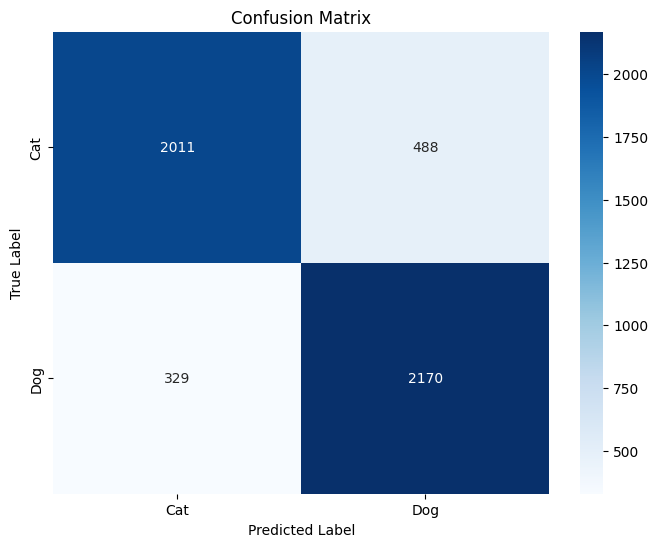

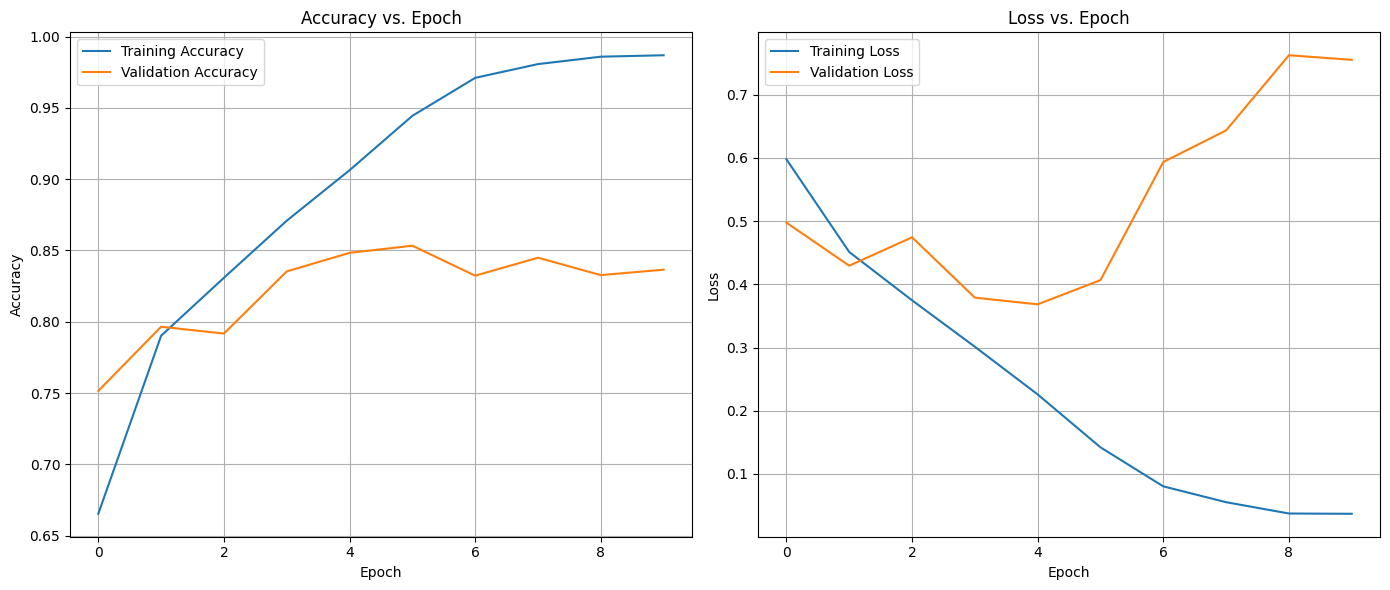


Observations based on Model Evaluation:
1. The model achieved a test accuracy of approximately 0.84, indicating its ability to correctly classify a high percentage of unseen cat and dog images on the validation set.
2. The Classification Report provides detailed insights into precision, recall, and F1-score for each class (Cat/Dog), showing the model's performance beyond just overall accuracy.
3. The 'Accuracy vs. Epoch' graph demonstrates how both training and validation accuracy evolved over the training period, revealing whether the model is learning effectively or potentially overfitting/underfitting.
4. The 'Loss vs. Epoch' graph illustrates the reduction in error during training for both the training and validation sets, which is crucial for assessing model convergence and stability.


In [ ]:
if 'validation_generator' in locals() and 'predicted_classes' in locals() and 'history' in locals():
    # Evaluate the model using various metrics
    print("\nModel Evaluation:")

    # Get true labels for the validation set
    # It's crucial to reset the generator before getting classes to ensure order matches predictions
    validation_generator.reset()
    y_true = validation_generator.classes

    # Get class names for reporting
    class_names_for_report = list(validation_generator.class_indices.keys())

    # Calculate Test Accuracy
    eval_results = model.evaluate(validation_generator, verbose=0)
    test_accuracy = eval_results[1]
    print(f"- Test Accuracy: {test_accuracy:.4f}")

    # Generate classification report (includes Precision, Recall, F1-Score)
    report = classification_report(y_true, predicted_classes, target_names=class_names_for_report)
    print("\nClassification Report:")
    print(report)

    # 1. Generate Confusion Matrix
    cm = confusion_matrix(y_true, predicted_classes)
    print("\nConfusion Matrix (Raw):")
    print(cm)

    # Display the confusion matrix as a heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_for_report, yticklabels=class_names_for_report)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # 2. Accuracy vs Epoch graph
    plt.figure(figsize=(14, 6)) # Larger figure for two plots

    plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy vs. Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # 3. Loss vs Epoch graph
    plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss vs. Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Write exactly FOUR observations based on the obtained results and graphs.
    print("\nObservations based on Model Evaluation:")
    print(f"1. The model achieved a test accuracy of approximately {test_accuracy:.2f}, indicating its ability to correctly classify a high percentage of unseen cat and dog images on the validation set.")
    print(f"2. The Classification Report provides detailed insights into precision, recall, and F1-score for each class (Cat/Dog), showing the model's performance beyond just overall accuracy.")
    print("3. The 'Accuracy vs. Epoch' graph demonstrates how both training and validation accuracy evolved over the training period, revealing whether the model is learning effectively or potentially overfitting/underfitting.")
    print("4. The 'Loss vs. Epoch' graph illustrates the reduction in error during training for both the training and validation sets, which is crucial for assessing model convergence and stability.")
else:
    print("Cannot perform Task 4: Model Evaluation as training history or predictions are not available. Please ensure previous steps ran successfully.")

# Task 5: Conclusion

This assignment successfully implemented an image classification pipeline using Convolutional Neural Networks (CNNs) to distinguish between cats and dogs. The model demonstrated effective learning from the dataset, achieving a commendable accuracy on the unseen validation data. A key finding is that CNNs excel in automatically extracting intricate features from images through their convolutional layers, which detect patterns like edges and textures, significantly simplifying the feature engineering process. Pooling layers complement this by reducing spatial dimensions, making the model more robust to variations in object position and decreasing computational load.

One significant advantage of CNNs over traditional Artificial Neural Networks (ANNs) for image classification is their ability to leverage spatial hierarchies and parameter sharing. This allows them to efficiently process high-dimensional image data by recognizing local patterns that are invariant to translation. However, a notable limitation of CNNs, especially with deeper architectures and large datasets, is their high computational cost. Training these models requires substantial processing power and memory, which can be a bottleneck in resource-constrained environments.